# Классификация: SI > медиана


## 1. Загрузка и подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle
import os
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('models', exist_ok=True)
RANDOM_STATE = 42

C:\Users\Kirill\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Загрузка данных
df = pd.read_csv('data_processed.csv')
medians_df = pd.read_csv('medians.csv')

# Получаем медиану SI
si_median = medians_df.loc[medians_df['target'] == 'SI', 'median'].values[0]
print(f"Медиана SI: {si_median:.4f}")

# Создаём бинарный таргет
df['target'] = (df['SI'] > si_median).astype(int)

print(f"\nБаланс классов:")
print(df['target'].value_counts())

Медиана SI: 3.8564

Баланс классов:
target
1    499
0    499
Name: count, dtype: int64


In [3]:
# Подготовка признаков
feature_cols = [col for col in df.columns if col not in ['IC50, mM', 'CC50, mM', 'SI', 'target']]
X = df[feature_cols]
y = df['target']

print(f"Количество признаков: {len(feature_cols)}")
print(f"Размер выборки: {X.shape[0]}")

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Масштабирование для линейных моделей
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Сохраняем scaler
with open('models/scaler_si_clf.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов в train: {np.bincount(y_train)}")
print(f"Баланс классов в test: {np.bincount(y_test)}")

Количество признаков: 165
Размер выборки: 998
Train: (798, 165), Test: (200, 165)
Баланс классов в train: [399 399]
Баланс классов в test: [100 100]


## 2. Обучение моделей

### Функция для расчёта метрик

In [4]:
def calculate_metrics(y_true, y_pred, y_proba, model_name):
    """Расчёт всех метрик для модели классификации"""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

results = []
models_dict = {}

### 2.1. Logistic Regression (бейзлайн)

In [5]:
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_train_pred_lr = lr_model.predict(X_train_scaled)
y_train_proba_lr = lr_model.predict_proba(X_train_scaled)[:, 1]
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_lr, y_train_proba_lr, 'Logistic Regression (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lr, y_test_proba_lr, 'Logistic Regression (test)'))

models_dict['Logistic Regression'] = {
    'model': lr_model,
    'y_pred': y_test_pred_lr,
    'y_proba': y_test_proba_lr,
    'is_scaled': True
}

print("Logistic Regression результаты:")
print(f"Train ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Logistic Regression результаты:
Train ROC-AUC: 0.8458, F1: 0.7541
Test  ROC-AUC: 0.6658, F1: 0.6256


### 2.2. Random Forest с GridSearchCV

In [6]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {rf_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {rf_grid.best_score_:.4f}")

rf_best = rf_grid.best_estimator_

y_train_pred_rf = rf_best.predict(X_train)
y_train_proba_rf = rf_best.predict_proba(X_train)[:, 1]
y_test_pred_rf = rf_best.predict(X_test)
y_test_proba_rf = rf_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_rf, y_train_proba_rf, 'Random Forest (train)'))
results.append(calculate_metrics(y_test, y_test_pred_rf, y_test_proba_rf, 'Random Forest (test)'))

models_dict['Random Forest'] = {
    'model': rf_best,
    'y_pred': y_test_pred_rf,
    'y_proba': y_test_proba_rf,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Лучшие параметры: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}
Лучший ROC-AUC (CV): 0.7551

Train ROC-AUC: 0.9721, F1: 0.9227
Test  ROC-AUC: 0.6948, F1: 0.6105


### 2.3. Gradient Boosting (sklearn) с GridSearchCV

In [7]:
gb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

gb_grid.fit(X_train, y_train)

print(f"Лучшие параметры: {gb_grid.best_params_}")
print(f"Лучший ROC-AUC (CV): {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_

y_train_pred_gb = gb_best.predict(X_train)
y_train_proba_gb = gb_best.predict_proba(X_train)[:, 1]
y_test_pred_gb = gb_best.predict(X_test)
y_test_proba_gb = gb_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_gb, y_train_proba_gb, 'Gradient Boosting (train)'))
results.append(calculate_metrics(y_test, y_test_pred_gb, y_test_proba_gb, 'Gradient Boosting (test)'))

models_dict['Gradient Boosting'] = {
    'model': gb_best,
    'y_pred': y_test_pred_gb,
    'y_proba': y_test_proba_gb,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Лучший ROC-AUC (CV): 0.7418

Train ROC-AUC: 0.9605, F1: 0.8875
Test  ROC-AUC: 0.6643, F1: 0.5864


### 2.4. XGBoost с Optuna

In [8]:
def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': RANDOM_STATE
    }
    
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='roc_auc', n_jobs=-1).mean()
    return score

xgb_study = optuna.create_study(direction='maximize')
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"Лучшие параметры: {xgb_study.best_params}")
print(f"Лучший ROC-AUC (CV): {xgb_study.best_value:.4f}")

xgb_best = XGBClassifier(**xgb_study.best_params, random_state=RANDOM_STATE)
xgb_best.fit(X_train, y_train)

y_train_pred_xgb = xgb_best.predict(X_train)
y_train_proba_xgb = xgb_best.predict_proba(X_train)[:, 1]
y_test_pred_xgb = xgb_best.predict(X_test)
y_test_proba_xgb = xgb_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_xgb, y_train_proba_xgb, 'XGBoost (train)'))
results.append(calculate_metrics(y_test, y_test_pred_xgb, y_test_proba_xgb, 'XGBoost (test)'))

models_dict['XGBoost'] = {
    'model': xgb_best,
    'y_pred': y_test_pred_xgb,
    'y_proba': y_test_proba_xgb,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Best trial: 22. Best value: 0.756109: 100%|██████████| 50/50 [01:12<00:00,  1.45s/it]


Лучшие параметры: {'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.010105037577073069, 'subsample': 0.8299227160909898, 'colsample_bytree': 0.8995276913236946, 'min_child_weight': 6}
Лучший ROC-AUC (CV): 0.7561

Train ROC-AUC: 0.9451, F1: 0.8785
Test  ROC-AUC: 0.6933, F1: 0.6154


### 2.5. LightGBM с Optuna

In [9]:
def lgbm_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'verbose': -1,
        'random_state': RANDOM_STATE
    }
    
    model = LGBMClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=5, 
                           scoring='roc_auc', n_jobs=-1).mean()
    return score

lgbm_study = optuna.create_study(direction='maximize')
lgbm_study.optimize(lgbm_objective, n_trials=100, show_progress_bar=True)

print(f"Лучшие параметры: {lgbm_study.best_params}")
print(f"Лучший ROC-AUC (CV): {lgbm_study.best_value:.4f}")

lgbm_best = LGBMClassifier(**lgbm_study.best_params, verbose=-1, random_state=RANDOM_STATE)
lgbm_best.fit(X_train, y_train)

y_train_pred_lgbm = lgbm_best.predict(X_train)
y_train_proba_lgbm = lgbm_best.predict_proba(X_train)[:, 1]
y_test_pred_lgbm = lgbm_best.predict(X_test)
y_test_proba_lgbm = lgbm_best.predict_proba(X_test)[:, 1]

results.append(calculate_metrics(y_train, y_train_pred_lgbm, y_train_proba_lgbm, 'LightGBM (train)'))
results.append(calculate_metrics(y_test, y_test_pred_lgbm, y_test_proba_lgbm, 'LightGBM (test)'))

models_dict['LightGBM'] = {
    'model': lgbm_best,
    'y_pred': y_test_pred_lgbm,
    'y_proba': y_test_proba_lgbm,
    'is_scaled': False
}

print(f"\nTrain ROC-AUC: {results[-2]['ROC-AUC']:.4f}, F1: {results[-2]['F1']:.4f}")
print(f"Test  ROC-AUC: {results[-1]['ROC-AUC']:.4f}, F1: {results[-1]['F1']:.4f}")

Best trial: 68. Best value: 0.751966: 100%|██████████| 100/100 [01:09<00:00,  1.45it/s]


Лучшие параметры: {'n_estimators': 150, 'max_depth': 9, 'learning_rate': 0.033125804568628625, 'subsample': 0.7362514024437841, 'colsample_bytree': 0.7521617186516717, 'num_leaves': 24, 'min_child_samples': 33}
Лучший ROC-AUC (CV): 0.7520

Train ROC-AUC: 0.9784, F1: 0.9259
Test  ROC-AUC: 0.6728, F1: 0.5979


### 2.6. Калибровка вероятностей

Калибруем модели, которые могут плохо оценивать вероятности (Logistic Regression и Random Forest)

In [10]:
# Калибровка Logistic Regression
lr_calibrated = CalibratedClassifierCV(lr_model, cv='prefit', method='isotonic')
lr_calibrated.fit(X_train_scaled, y_train)

y_test_proba_lr_cal = lr_calibrated.predict_proba(X_test_scaled)[:, 1]
y_test_pred_lr_cal = (y_test_proba_lr_cal > 0.5).astype(int)

results.append(calculate_metrics(y_test, y_test_pred_lr_cal, y_test_proba_lr_cal, 'Logistic Regression Calibrated'))

models_dict['Logistic Regression Calibrated'] = {
    'model': lr_calibrated,
    'y_pred': y_test_pred_lr_cal,
    'y_proba': y_test_proba_lr_cal,
    'is_scaled': True
}

print(f"Logistic Regression Calibrated: ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

# Калибровка Random Forest
rf_calibrated = CalibratedClassifierCV(rf_best, cv='prefit', method='isotonic')
rf_calibrated.fit(X_train, y_train)

y_test_proba_rf_cal = rf_calibrated.predict_proba(X_test)[:, 1]
y_test_pred_rf_cal = (y_test_proba_rf_cal > 0.5).astype(int)

results.append(calculate_metrics(y_test, y_test_pred_rf_cal, y_test_proba_rf_cal, 'Random Forest Calibrated'))

models_dict['Random Forest Calibrated'] = {
    'model': rf_calibrated,
    'y_pred': y_test_pred_rf_cal,
    'y_proba': y_test_proba_rf_cal,
    'is_scaled': False
}

print(f"Random Forest Calibrated: ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

Logistic Regression Calibrated: ROC-AUC = 0.6641
Random Forest Calibrated: ROC-AUC = 0.6817


## 3. Сравнение моделей

In [11]:
results_df = pd.DataFrame(results)
print("\nВсе результаты:")
print(results_df.to_string(index=False))

test_results = results_df[results_df['Model'].str.contains('test|Calibrated')].copy()
test_results['Model'] = test_results['Model'].str.replace(' \(test\)', '')
test_results = test_results.sort_values('ROC-AUC', ascending=False)

print("Рейтинг моделей по ROC-AUC на тестовой выборке:")
for i, row in test_results.iterrows():
    print(f"{row['Model']:<35} ROC-AUC={row['ROC-AUC']:.4f}, F1={row['F1']:.4f}, Acc={row['Accuracy']:.4f}")


Все результаты:
                         Model  Accuracy  Precision   Recall       F1  ROC-AUC
   Logistic Regression (train)  0.753133   0.751244 0.756892 0.754057 0.845824
    Logistic Regression (test)  0.635000   0.642105 0.610000 0.625641 0.665850
         Random Forest (train)  0.921053   0.903846 0.942356 0.922699 0.972136
          Random Forest (test)  0.630000   0.644444 0.580000 0.610526 0.694850
     Gradient Boosting (train)  0.885965   0.875610 0.899749 0.887515 0.960525
      Gradient Boosting (test)  0.605000   0.615385 0.560000 0.586387 0.664350
               XGBoost (train)  0.875940   0.860577 0.897243 0.878528 0.945145
                XGBoost (test)  0.625000   0.631579 0.600000 0.615385 0.693250
              LightGBM (train)  0.924812   0.912409 0.939850 0.925926 0.978380
               LightGBM (test)  0.610000   0.617021 0.580000 0.597938 0.672750
Logistic Regression Calibrated  0.620000   0.630435 0.580000 0.604167 0.664100
      Random Forest Calibrated  0.6

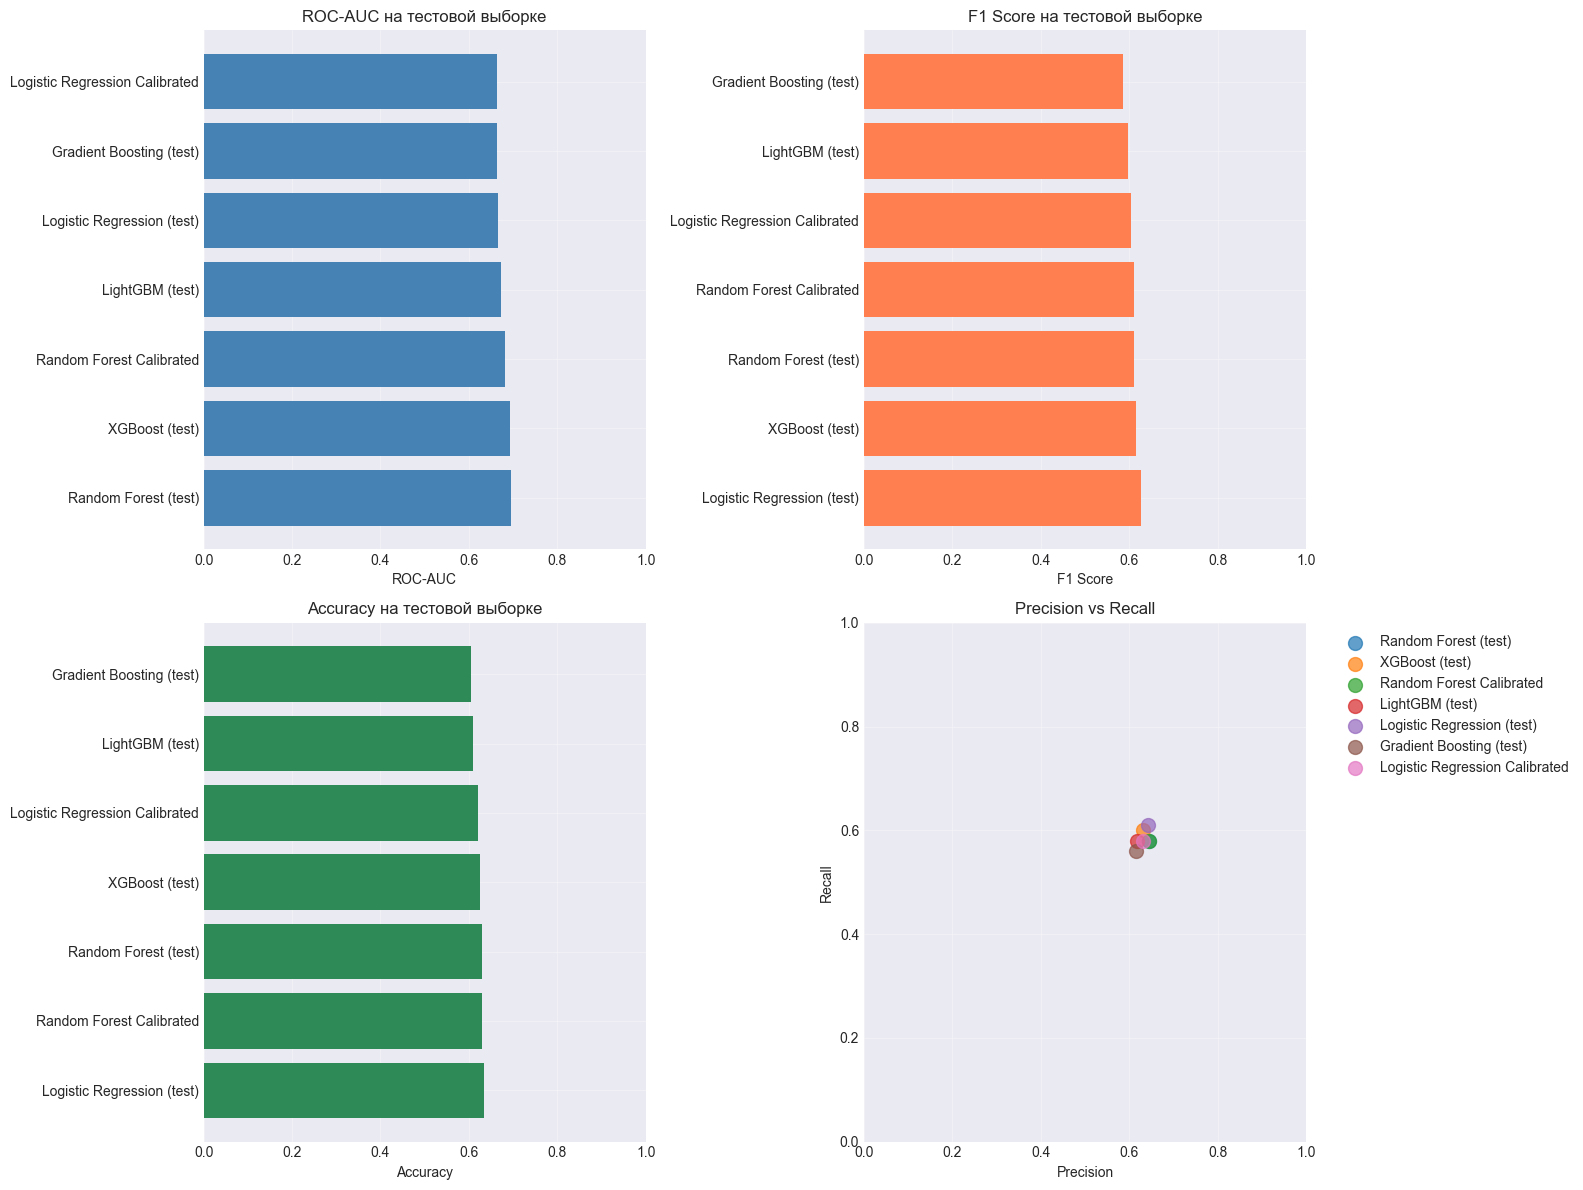

In [12]:
# Визуализация сравнения
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROC-AUC
test_results_sorted = test_results.sort_values('ROC-AUC', ascending=False)
axes[0, 0].barh(test_results_sorted['Model'], test_results_sorted['ROC-AUC'], color='steelblue')
axes[0, 0].set_xlabel('ROC-AUC')
axes[0, 0].set_title('ROC-AUC на тестовой выборке')
axes[0, 0].set_xlim(0, 1)
axes[0, 0].grid(True, alpha=0.3)

# F1 Score
test_results_sorted = test_results.sort_values('F1', ascending=False)
axes[0, 1].barh(test_results_sorted['Model'], test_results_sorted['F1'], color='coral')
axes[0, 1].set_xlabel('F1 Score')
axes[0, 1].set_title('F1 Score на тестовой выборке')
axes[0, 1].set_xlim(0, 1)
axes[0, 1].grid(True, alpha=0.3)

# Accuracy
test_results_sorted = test_results.sort_values('Accuracy', ascending=False)
axes[1, 0].barh(test_results_sorted['Model'], test_results_sorted['Accuracy'], color='seagreen')
axes[1, 0].set_xlabel('Accuracy')
axes[1, 0].set_title('Accuracy на тестовой выборке')
axes[1, 0].set_xlim(0, 1)
axes[1, 0].grid(True, alpha=0.3)

# Precision vs Recall
for _, row in test_results.iterrows():
    axes[1, 1].scatter(row['Precision'], row['Recall'], s=100, label=row['Model'], alpha=0.7)
axes[1, 1].set_xlabel('Precision')
axes[1, 1].set_ylabel('Recall')
axes[1, 1].set_title('Precision vs Recall')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 4. Детальный анализ лучшей модели

In [13]:
# Определяем лучшую модель
best_model_name_raw = test_results.iloc[0]['Model']
best_model_name = best_model_name_raw.replace(' (test)', '').strip()

best_model_info = models_dict[best_model_name]
best_model = best_model_info['model']
y_pred_best = best_model_info['y_pred']
y_proba_best = best_model_info['y_proba']

print(f"Лучшая модель: {best_model_name}")
print(f"\nМетрики на тестовой выборке:")
print(f"Accuracy: {test_results.iloc[0]['Accuracy']:.4f}")
print(f"Precision: {test_results.iloc[0]['Precision']:.4f}")
print(f"Recall: {test_results.iloc[0]['Recall']:.4f}")
print(f"F1: {test_results.iloc[0]['F1']:.4f}")
print(f"ROC-AUC: {test_results.iloc[0]['ROC-AUC']:.4f}")
print(classification_report(y_test, y_pred_best, digits=4))

Лучшая модель: Random Forest

Метрики на тестовой выборке:
Accuracy: 0.6300
Precision: 0.6444
Recall: 0.5800
F1: 0.6105
ROC-AUC: 0.6948
              precision    recall  f1-score   support

           0     0.6182    0.6800    0.6476       100
           1     0.6444    0.5800    0.6105       100

    accuracy                         0.6300       200
   macro avg     0.6313    0.6300    0.6291       200
weighted avg     0.6313    0.6300    0.6291       200



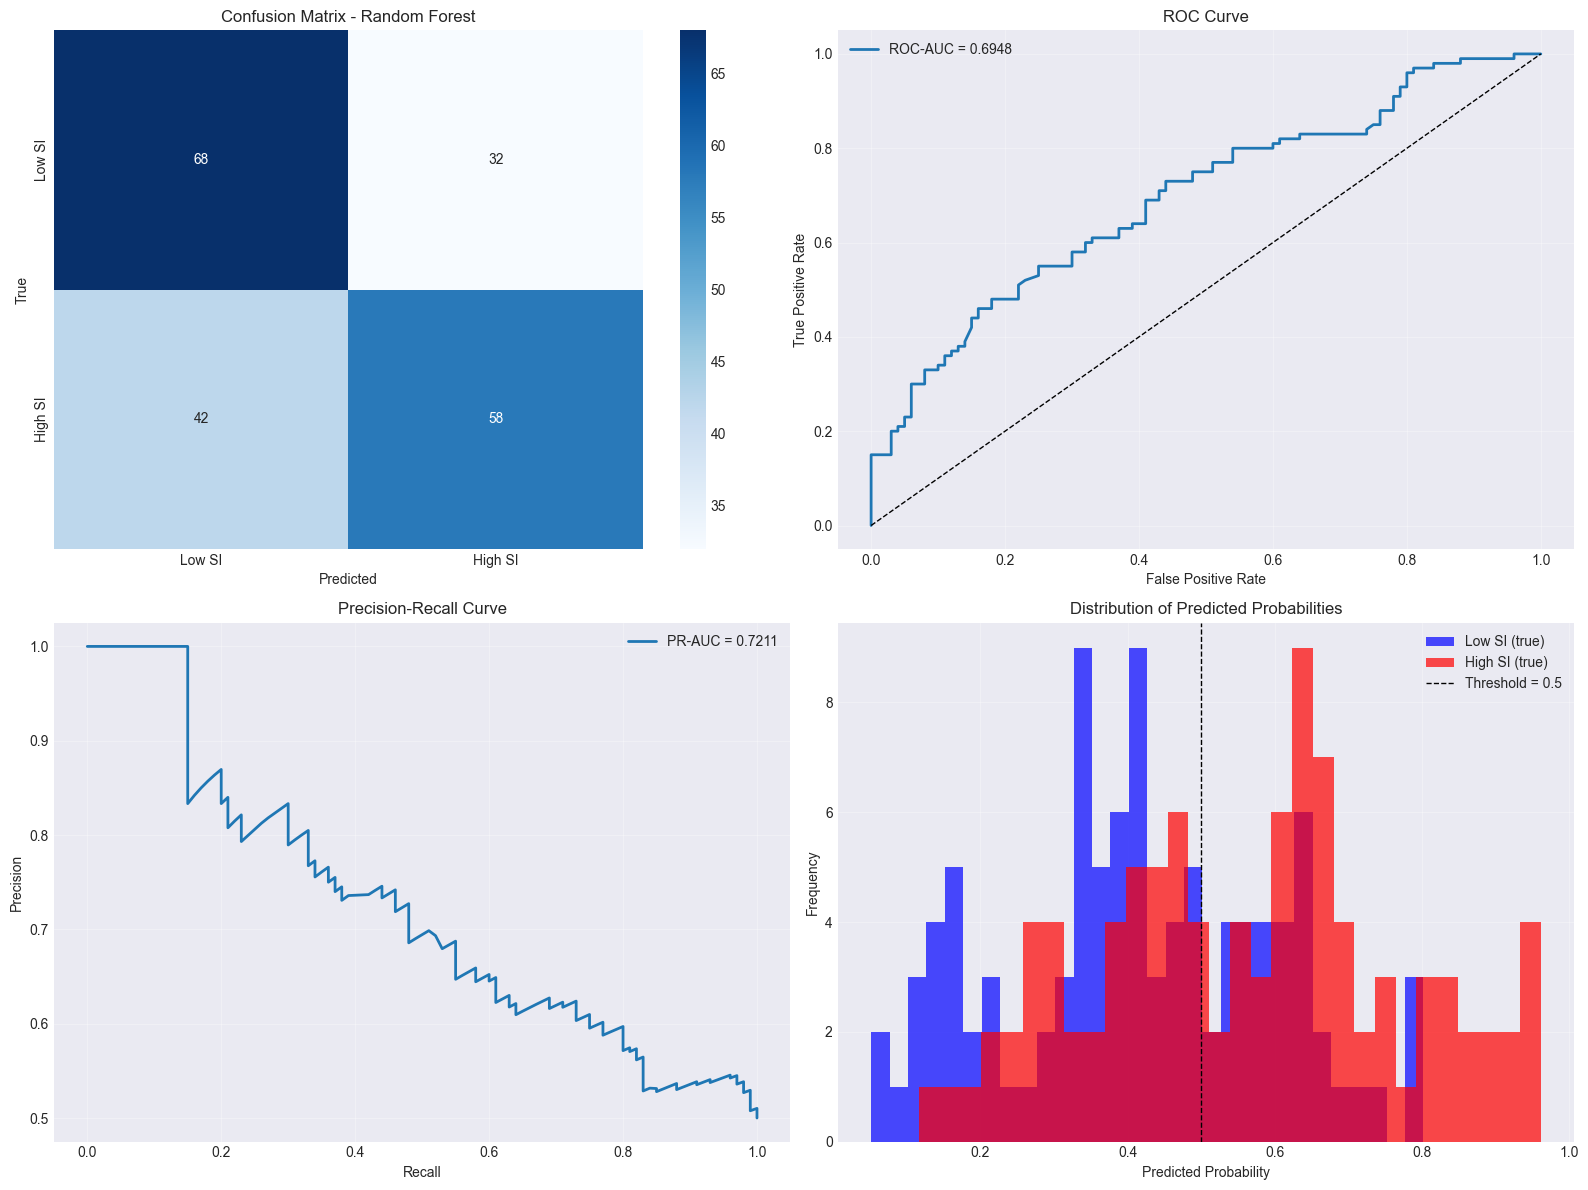

In [14]:
# Визуализация метрик лучшей модели
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], 
            xticklabels=['Low SI', 'High SI'], yticklabels=['Low SI', 'High SI'])
axes[0, 0].set_title(f'Confusion Matrix - {best_model_name}')
axes[0, 0].set_ylabel('True')
axes[0, 0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_best)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, lw=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba_best)
pr_auc = auc(recall, precision)
axes[1, 0].plot(recall, precision, lw=2, label=f'PR-AUC = {pr_auc:.4f}')
axes[1, 0].set_xlabel('Recall')
axes[1, 0].set_ylabel('Precision')
axes[1, 0].set_title('Precision-Recall Curve')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Распределение предсказанных вероятностей
axes[1, 1].hist(y_proba_best[y_test == 0], bins=30, alpha=0.7, label='Low SI (true)', color='blue')
axes[1, 1].hist(y_proba_best[y_test == 1], bins=30, alpha=0.7, label='High SI (true)', color='red')
axes[1, 1].axvline(0.5, color='black', linestyle='--', lw=1, label='Threshold = 0.5')
axes[1, 1].set_xlabel('Predicted Probability')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Predicted Probabilities')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Важность признаков

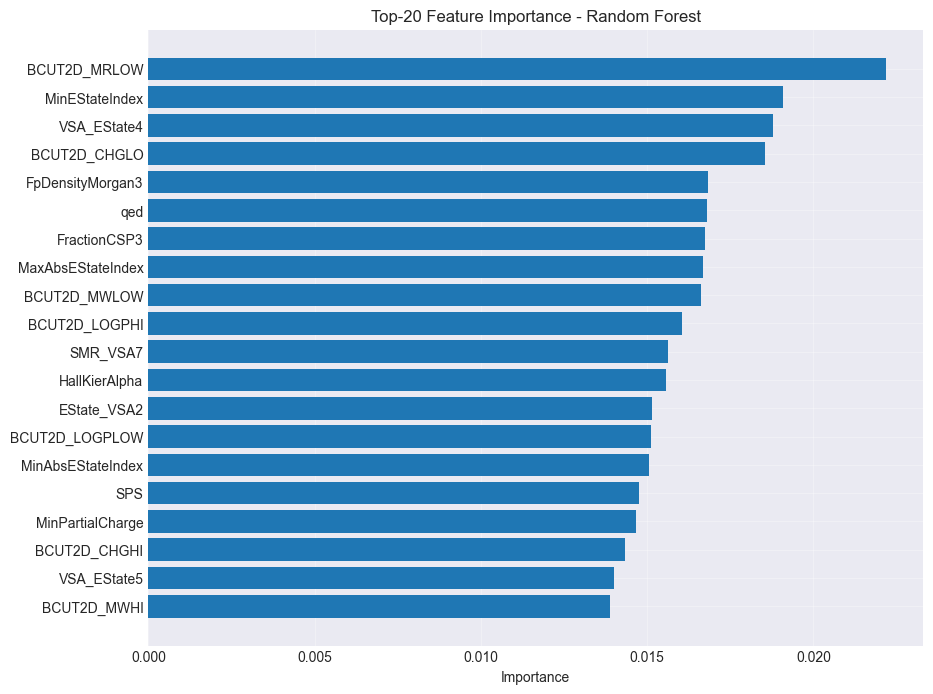


Топ-10 важных признаков:
          Feature  Importance
     BCUT2D_MRLOW    0.022199
   MinEStateIndex    0.019076
      VSA_EState4    0.018784
     BCUT2D_CHGLO    0.018542
 FpDensityMorgan3    0.016842
              qed    0.016810
     FractionCSP3    0.016729
MaxAbsEStateIndex    0.016679
     BCUT2D_MWLOW    0.016614
    BCUT2D_LOGPHI    0.016044


In [15]:
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance')
plt.title(f'Top-20 Feature Importance - {best_model_name}')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("\nТоп-10 важных признаков:")
print(feature_importance.head(10).to_string(index=False))

## 6. Сохранение лучшей модели

In [16]:
metrics_to_save = test_results.iloc[0].to_dict()
metrics_to_save['Model'] = best_model_name

model_info = {
    'model': best_model,
    'model_name': best_model_name,
    'features': feature_cols,
    'scaler': scaler,
    'threshold': si_median,
    'is_scaled': best_model_info['is_scaled'],
    'metrics': metrics_to_save
}

with open('models/best_si_classification_median.pkl', 'wb') as f:
    pickle.dump(model_info, f)

print(f"Лучшая модель сохранена: models/best_si_classification_median.pkl")
print(f"\nМодель: {best_model_name}")
print(f"Метрики: ROC-AUC={test_results.iloc[0]['ROC-AUC']:.4f}, F1={test_results.iloc[0]['F1']:.4f}")

Лучшая модель сохранена: models/best_si_classification_median.pkl

Модель: Random Forest
Метрики: ROC-AUC=0.6948, F1=0.6105


## 7. Выводы и рекомендации

### Рекомендации по улучшению

1. **Генерация новых признаков**
   - Создание взаимодействий между важными дескрипторами
   - Доменные знания о SAR

2. **Ансамблирование**
   - Стекинг лучших моделей (XGBoost + LightGBM + RF)
   - Голосование между калиброванными моделями

### Заключение

Лучшие модели показывают сопоставимые результаты. Можно использовать стекинг для максимального качества